# Crop Disease AI — Week 1: EDA
**Author:** Shaik Hafeez Jan | B.Tech AIML Final Year
**Dataset:** PlantVillage (38 classes, 54,000+ images)

In [1]:
# Cell 1: Check GPU
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU — go to Settings > Accelerator > GPU T4')

CUDA available: True
GPU: Tesla T4


In [2]:
# Cell 2: Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
print('All imports done!')

All imports done!


In [3]:
# Cell 3: Correct path for your dataset
from pathlib import Path

# Check what's inside
base = Path('/kaggle/input/datasets/abdallahalidev/plantvillage-dataset')
print("=== Folder structure ===")
for item in sorted(base.iterdir()):
    print(f"  {item.name}")
    if item.is_dir():
        subs = list(item.iterdir())[:3]
        for s in subs:
            print(f"    └── {s.name}")

=== Folder structure ===
  color
    └── Tomato___Late_blight
    └── Tomato___healthy
    └── Grape___healthy
  grayscale
    └── Tomato___Late_blight
    └── Tomato___healthy
    └── Grape___healthy
  plantvillage dataset
    └── segmented
    └── grayscale
    └── color
  segmented
    └── Tomato___Late_blight
    └── Tomato___healthy
    └── Grape___healthy


In [4]:
# Cell 4: FINAL correct path
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color')

print(f'Dataset path: {DATA_DIR}')
print(f'Path exists: {DATA_DIR.exists()}')

classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f'Total classes found: {len(classes)}')
print('First 5 classes:', classes[:5])

Dataset path: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Path exists: True
Total classes found: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [5]:
# Cell 5: Count images per class
class_counts = {}
for cls in classes:
    cls_path = DATA_DIR / cls
    count = len(list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.JPG')) + list(cls_path.glob('*.png')))
    class_counts[cls] = count

total = sum(class_counts.values())
print(f'Total images: {total:,}')
print(f'Average per class: {total//len(classes)}')
print(f'Min class: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} images)')
print(f'Max class: {max(class_counts, key=class_counts.get)} ({max(class_counts.values())} images)')

Total images: 54,304
Average per class: 1429
Min class: Potato___healthy (152 images)
Max class: Orange___Haunglongbing_(Citrus_greening) (5507 images)


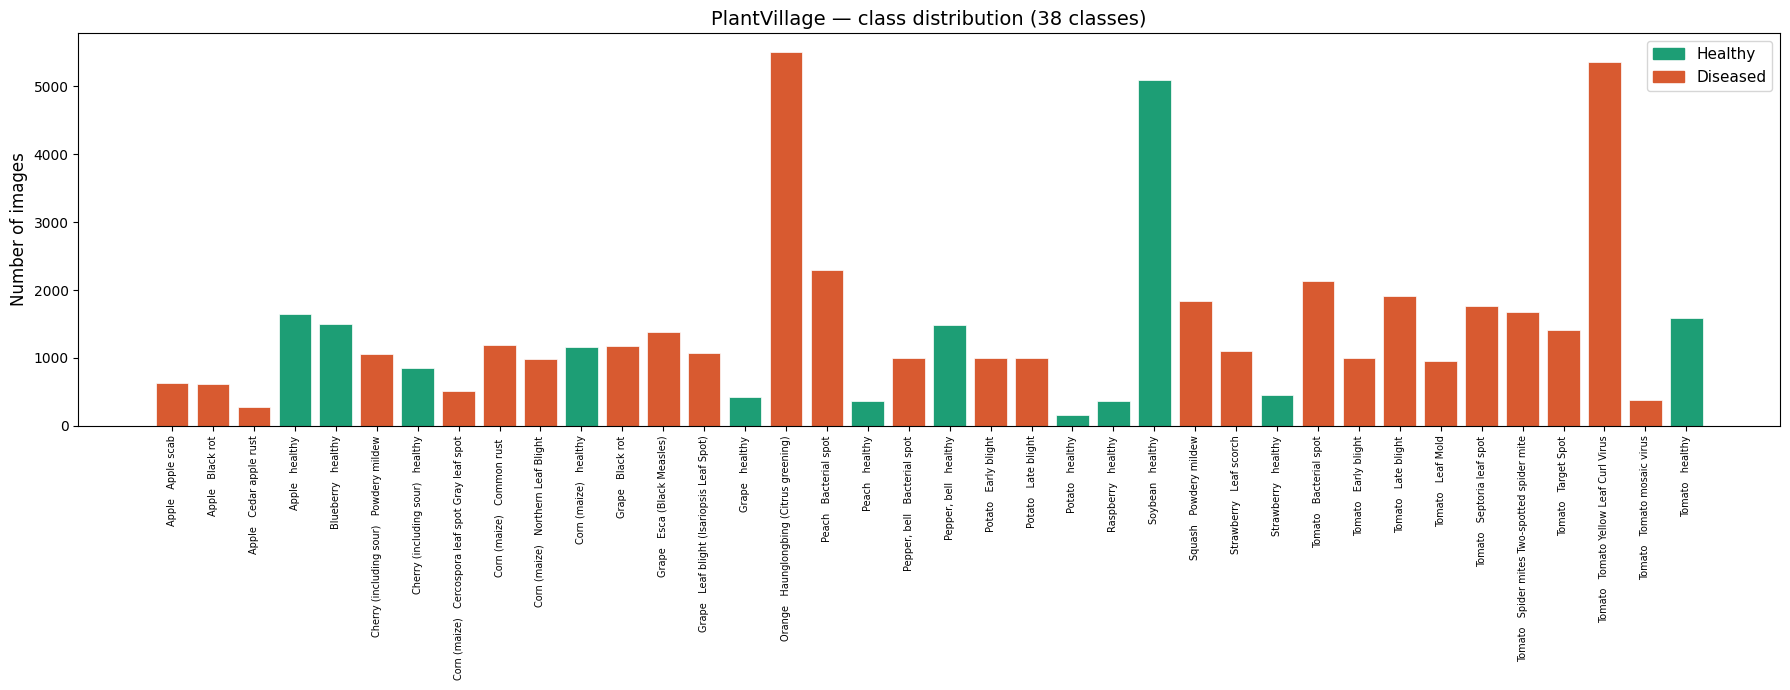

Chart saved!


In [6]:
# Cell 6: Class distribution bar chart
fig, ax = plt.subplots(figsize=(18, 7))

# Colour: healthy = green, diseased = coral
colors = ['#1D9E75' if 'healthy' in cls.lower() else '#D85A30' for cls in class_counts.keys()]
bars = ax.bar(range(len(class_counts)), list(class_counts.values()), color=colors, edgecolor='white', linewidth=0.5)

ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels([c.replace('_', ' ') for c in class_counts.keys()], rotation=90, fontsize=7)
ax.set_ylabel('Number of images', fontsize=12)
ax.set_title('PlantVillage — class distribution (38 classes)', fontsize=14, fontweight='500')

healthy_patch = mpatches.Patch(color='#1D9E75', label='Healthy')
disease_patch = mpatches.Patch(color='#D85A30', label='Diseased')
ax.legend(handles=[healthy_patch, disease_patch], fontsize=11)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

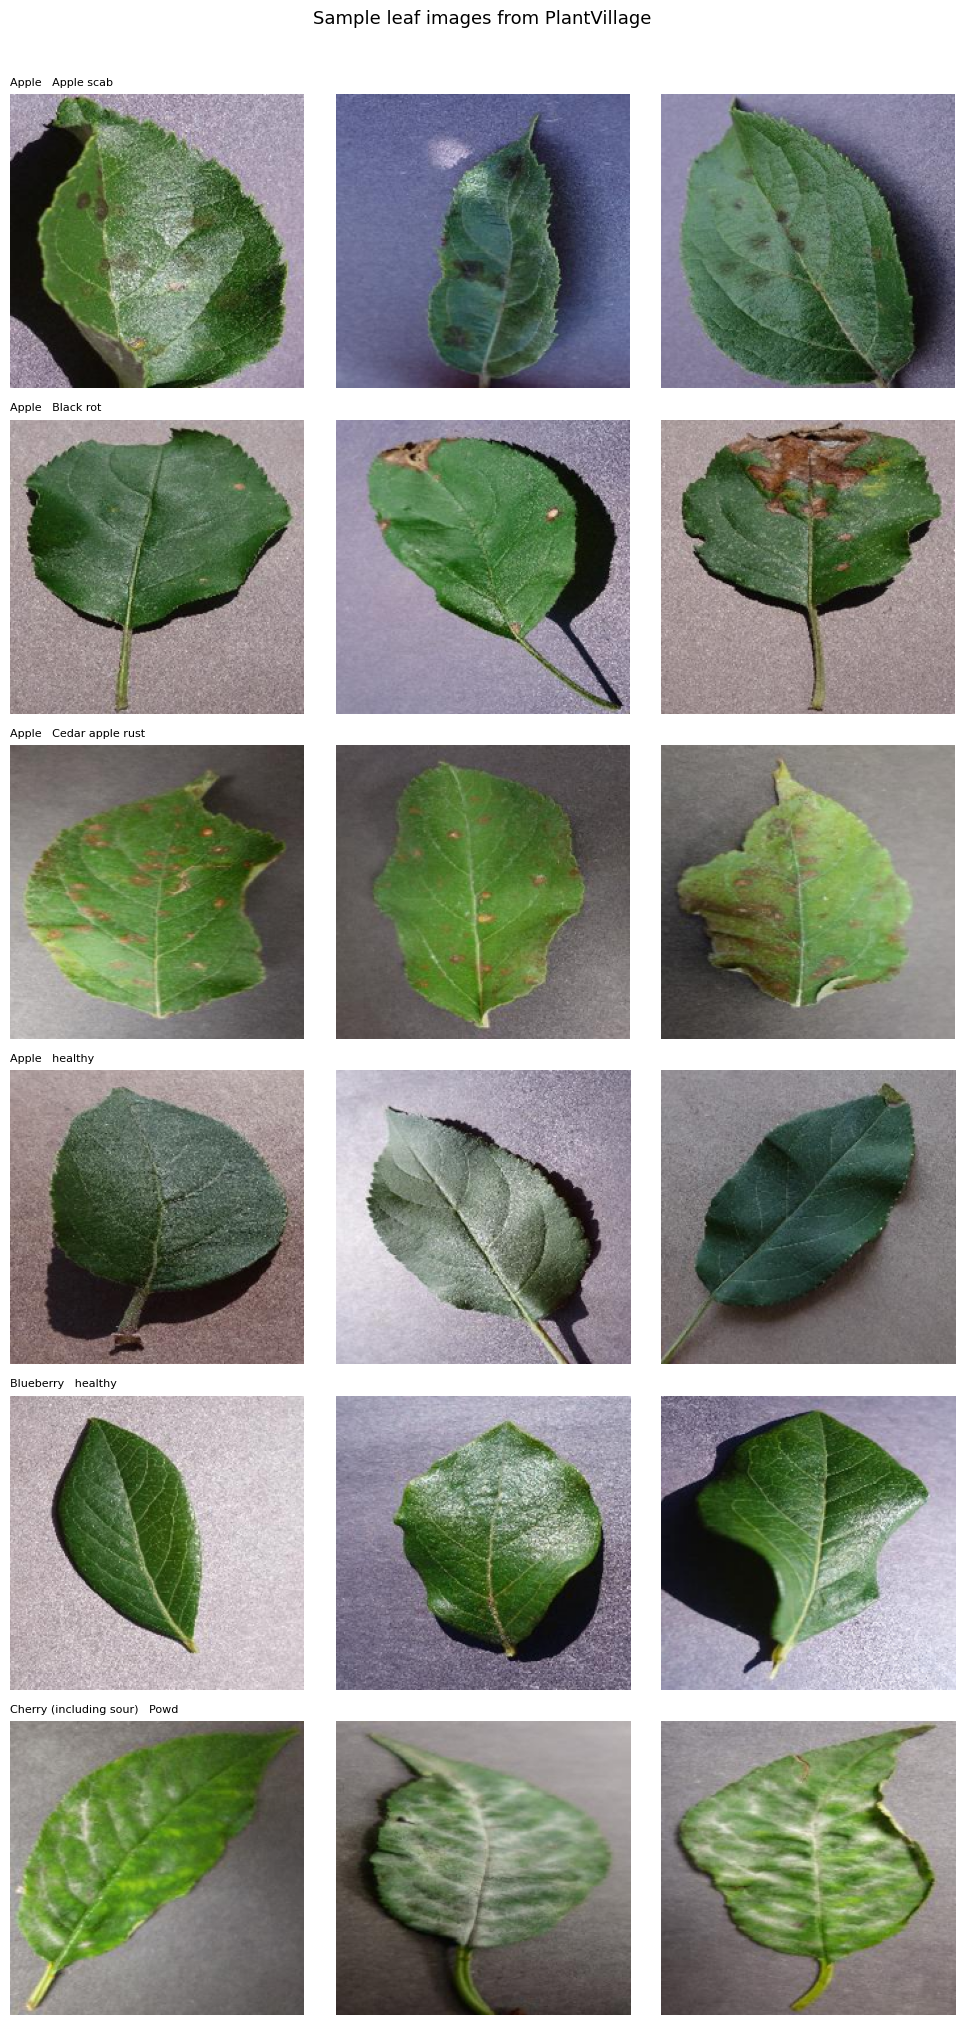

In [7]:
# Cell 7: Show sample images (3 per class, first 6 classes)
fig, axes = plt.subplots(6, 3, figsize=(10, 20))
sample_classes = classes[:6]

for row, cls in enumerate(sample_classes):
    cls_path = DATA_DIR / cls
    images = list(cls_path.glob('*.jpg'))[:3] + list(cls_path.glob('*.JPG'))[:3]
    images = images[:3]
    for col, img_path in enumerate(images):
        img = Image.open(img_path).resize((224, 224))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls.replace('_', ' ')[:30], fontsize=8, loc='left')

plt.suptitle('Sample leaf images from PlantVillage', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Cell 8: Check image sizes (are they consistent?)
sample_sizes = []
for cls in classes[:5]:
    cls_path = DATA_DIR / cls
    imgs = list(cls_path.glob('*.jpg'))[:20]
    for p in imgs:
        with Image.open(p) as im:
            sample_sizes.append(im.size)

unique_sizes = Counter(sample_sizes)
print('Most common image sizes (W x H):')
for size, count in unique_sizes.most_common(5):
    print(f'  {size}: {count} images')

Most common image sizes (W x H):


In [9]:
# Cell 9: Train / Val / Test split summary
import math

splits = {'train': 0.70, 'val': 0.15, 'test': 0.15}
print('Proposed dataset split:')
print(f'{"Split":<10} {"Ratio":<10} {"Images":<10}')
print('-' * 30)
for split, ratio in splits.items():
    print(f'{split:<10} {ratio:<10} {math.floor(total * ratio):<10,}')

print(f'\nTotal: {total:,} images across {len(classes)} classes')
print('Ready for training!')

Proposed dataset split:
Split      Ratio      Images    
------------------------------
train      0.7        38,012    
val        0.15       8,145     
test       0.15       8,145     

Total: 54,304 images across 38 classes
Ready for training!


In [10]:
# Cell 10: Save class list for later use by model
import json
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
with open('class_to_idx.json', 'w') as f:
    json.dump(class_to_idx, f, indent=2)
print(f'Saved class_to_idx.json with {len(class_to_idx)} classes')
print('\nEDA complete! Next: run 02_train.ipynb')

Saved class_to_idx.json with 38 classes

EDA complete! Next: run 02_train.ipynb
